# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Load the processed dataset as CSV files in S3 bucket.</br>
    4.2. Identify the top 5 counties with the highest number of collisions.</br>
    4.3. Identify the month with the highest number of collisions.</br>
    4.4. Determine the most common weather condition during collisions.</br>
    4.5. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.6. Find the most dangerous time of day for collisions.</br>
    4.7. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.8. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Install Required Libraries

In [2]:
## Install the required libraries
# !pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [3]:
# Import the necessary libraries
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, to_date

# **1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [4]:
spark = SparkSession.builder.appName("Traffic_analysis").getOrCreate()

In [5]:
# Write code to load the data and check the schema
case_ids_df = spark.read.csv("Sample_datasets/sample_case_ids.csv", inferSchema=True, header = True)
collisions_df = spark.read.csv("Sample_datasets/sample_collisions.csv", inferSchema = True, header = True)
parties_df = spark.read.csv("Sample_datasets/sample_parties.csv", inferSchema = True, header = True)
victims_df = spark.read.csv("Sample_datasets/sample_victims.csv", inferSchema=True, header = True )

# **2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [6]:
tables = {"case_ids": case_ids_df,  
          "collisions": collisions_df,  
          "victims" : victims_df, 
          "parties": parties_df}

In [7]:
# Display Schema & Sample Data

for  name, df in tables.items(): 
    print(f"The Schema of {name} table is : ")
    print(df.printSchema())

The Schema of case_ids table is : 
root
 |-- case_id: double (nullable = true)
 |-- db_year: integer (nullable = true)

None
The Schema of collisions table is : 
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = t

In [8]:
for name , df in tables.items(): 
    print(f"The sample rows of {name} table is : ")
    if name == "case_ids": 
        print(df.show(2))
    else: 
        print(df.show(1, vertical = True))

The sample rows of case_ids table is : 
+-----------+-------+
|    case_id|db_year|
+-----------+-------+
|9.0017156E7|   2021|
|  4078685.0|   2021|
+-----------+-------+
only showing top 2 rows

None
The sample rows of collisions table is : 
-RECORD 0-----------------------------------------------
 case_id                         | 8000993.0            
 jurisdiction                    | 1942.0               
 officer_id                      | 39335                
 reporting_district              | 1676                 
 chp_shift                       | not chp              
 population                      | >250000              
 county_city_location            | 1942                 
 county_location                 | los angeles          
 special_condition               | 0.0                  
 beat_type                       | not chp              
 chp_beat_type                   | not chp              
 chp_beat_class                  | not chp              
 beat_number   

## **2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [9]:
#Check for Missing Values
from pyspark.sql.functions import col, count ,when

def missing_check(df): 
    total_rows = df.count() 
    check = []
    for c in df.columns: 
        missing = df.filter(col(c).isNull()).count() 
        check.append((c, missing, round(missing/total_rows *100, 2)))
    return check


In [10]:
for name, df  in tables.items() : 
    print(f"The percentage  of missing value in each column of {name} table :\
    \n Shown as (column name,  missing rows, missing rows percentage)")
    print(missing_check(df))

The percentage  of missing value in each column of case_ids table :    
 Shown as (column name,  missing rows, missing rows percentage)
[('case_id', 0, 0.0), ('db_year', 0, 0.0)]
The percentage  of missing value in each column of collisions table :    
 Shown as (column name,  missing rows, missing rows percentage)
[('case_id', 0, 0.0), ('jurisdiction', 1158, 0.12), ('officer_id', 2264, 0.24), ('reporting_district', 552653, 59.06), ('chp_shift', 0, 0.0), ('population', 165, 0.02), ('county_city_location', 0, 0.0), ('county_location', 0, 0.0), ('special_condition', 51730, 5.53), ('beat_type', 0, 0.0), ('chp_beat_type', 0, 0.0), ('chp_beat_class', 274, 0.03), ('beat_number', 80780, 8.63), ('primary_road', 10, 0.0), ('secondary_road', 2, 0.0), ('distance', 0, 0.0), ('direction', 232663, 24.86), ('intersection', 9484, 1.01), ('weather_1', 4626, 0.49), ('state_highway_indicator', 318, 0.03), ('caltrans_county', 682075, 72.89), ('caltrans_district', 648728, 69.32), ('state_route', 648728, 69

In [11]:
#Drop Sparse Columns 
# I have choosen 67 as threshold_pct as it reflects two-third of whole count.
geo_column =["latitude", "longitude"] # I have excluded this column inspite for having such a great percentage of missing values
                                      # as they are valuable columns which may give us some insights later on
def drop_sparse(df, threshold_pct = 67): 
    sparse = []
    for col_name, missing, missing_pct in missing_check(df): 
        if col_name in geo_column: 
           continue
        if missing_pct > threshold_pct: 
            sparse.append(col_name)
     
    if len(sparse) != 0 :
        print(f"The number of sparse columns in {name} tables are: {len(sparse)}, and \n \
        they are {sparse}" )
        print("These columns are dropped")
    df  = df.drop(*sparse)
    return df
    
clean_tables = {}
for name, df in tables.items(): 
    clean_tables[name] = drop_sparse(df)
  

The number of sparse columns in collisions tables are: 6, and 
         they are ['caltrans_county', 'caltrans_district', 'state_route', 'postmile', 'location_type', 'side_of_highway']
These columns are dropped


In [12]:
# Convert Data Types
# Most of the columns have the right datatype as I read the csv files with inferSchema = True
"""case_ids table has only two columns and they are numeric so there's nothing to convert 
victims and parties table has a few string columns which I check manually by comparing their schema and first row,
 from where I am confident that those columns have the right data type
As collisions have 50 + columns I first excluded those who have string data type and checked their first row, from where I 
am sure that only two columns 'officer_id' and 'reporting_district' are suscpicious enough that they could be numeric. """
from pyspark.sql.types import StringType
string_cols = [field.name for field in clean_tables["collisions"].schema.fields if isinstance(field.dataType, StringType) ]

print(f"String columns ({len(string_cols)}):")
clean_tables["collisions"].select(string_cols).show(1 , vertical= True)



String columns (27):
-RECORD 0-----------------------------------------------
 officer_id                      | 39335                
 reporting_district              | 1676                 
 chp_shift                       | not chp              
 population                      | >250000              
 county_location                 | los angeles          
 beat_type                       | not chp              
 chp_beat_type                   | not chp              
 chp_beat_class                  | not chp              
 beat_number                     | 9TL56                
 primary_road                    | NETTLETON ST         
 secondary_road                  | GLENOAKS             
 direction                       | west                 
 weather_1                       | clear                
 collision_severity              | property damage only 
 primary_collision_factor        | vehicle code viol... 
 pcf_violation_category          | improper turning     
 pcf_viola

In [13]:
""" That's why I checked the distinct values of these two columns only and it is clearly seen these are true categorical string columns.
There's nothing to convert. """

clean_tables['collisions'].select("officer_id", "reporting_district").distinct().show()

+----------+------------------+
|officer_id|reporting_district|
+----------+------------------+
|       234|                 2|
|     44356|              0701|
|      1738|             922C3|
|      3662|             FOOTH|
|     N6251|              920A|
|        21|             STHEL|
|     D2004|              YV19|
|      4576|                14|
|     11572|             AD310|
|     13746|                 0|
|      3226|             FOOTH|
|      9972|                 0|
|     39976|              1263|
|     38394|              1494|
|     10106|             PATRO|
|      4072|                 0|
|     27820|              0357|
|     40602|              0526|
|      1452|               17E|
|     40724|                87|
+----------+------------------+
only showing top 20 rows



In [14]:
# Handle Missing Values
# To handle missing values I have to apply different techniques for different columns. 

def handle_missing_primary(df): 
    low_missing = [] ; mid_missing = [] ; high_missing = []
    for col_name, _, missing_pct in missing_check(df): 
        if missing_pct < 1 : 
            low_missing.append(col_name)        
        elif missing_pct < 20 : 
            mid_missing.append(col_name) 
        else: 
            high_missing.append(col_name)
    df = df.dropna(subset = low_missing)  # Dropping those rows of those columns which have lesst than 1 % of missing values.
    string_cols_missing = [ field.name for field in df.schema.fields if isinstance(field.dataType, StringType) and field.name in mid_missing]
    df = df.fillna("unknown", subset = string_cols_missing)
    other_mid_missing = [col_name for col_name in mid_missing if col_name not in string_cols_missing]
    print("These are the columns that are untouched by this operation : ")
    print(f"Non- String columns that have medium missing values : {other_mid_missing}" ) 
    print(f"Columns that have high missing values : {high_missing}")
    return df , other_mid_missing , high_missing


In [15]:
# Checking victims table
df, mid, high = handle_missing_primary(clean_tables['victims'])
df.select("victim_safety_equipment_2").groupby("victim_safety_equipment_2").count().show()
# for victim_age column I decided to keep those null values as it doesn't make sense to impute those rows with soem other values as it would harm my analysis.
# From here I decide to fill those missing values as Unknown as it makes much sense. 

df = df.withColumn( "victim_safety_equipment_2",
                        when( col("victim_safety_equipment_2").isNull(), "unknown").otherwise(col("victim_safety_equipment_2"))
                    )
print("Final cleaning complete for victims table")
clean_tables['victims'] = df

These are the columns that are untouched by this operation : 
Non- String columns that have medium missing values : ['victim_age']
Columns that have high missing values : ['victim_safety_equipment_2']
+-------------------------+------+
|victim_safety_equipment_2| count|
+-------------------------+------+
|     passenger, motorc...|   274|
|         air bag deployed|  3113|
|             not required|  5113|
|     lap/shoulder harn...|524499|
|                  unknown|  9906|
|                     NULL|306314|
|     no child restrain...|  1267|
|     shoulder harness ...|  1282|
|     child restraint i...|   499|
|     lap/shoulder harn...| 11167|
|     passive restraint...|   742|
|     passive restraint...|   145|
|                    other|   346|
|     driver, motorcycl...|  7704|
|            lap belt used|  9786|
|     air bag not deployed|  3638|
|        lap belt not used|  1293|
|     shoulder harness ...|  2524|
|     passenger, motorc...|  1129|
|     child restraint i...|  

In [16]:
# checking parties table
df , mid , high = handle_missing_primary(clean_tables['parties'])

print("These are the numeric columns with medium missing value percentage: ")
for colm in mid : 
    df.select(colm).groupby(colm).count().orderBy("count", ascending = False).show(5)

# These are numeric categorical columns , they are representing  attibutes, imputing them with mode would harm the data. 

print("These are the columns with high missing value percentage: ")
for colm in high: 
     df.select(colm).groupby(colm).count().orderBy("count", ascending = False).show(5)

""" Observing these columns different measures need to taken for different columns . 
party_safety_equipment = labelling as 'unknown'  
cellphone_in_use = do nothing as there are only 0 and 1 value 
cellphone_use_type = merging the null value with no cellphone/unknown column
chp_vehicle_type_towing = labellign as 'unknown' 
chp_vehicle_type_towed = labelling as 'unknown' and also merging '0' and '00' as not towed category
party_race = 'unknown'"""

high.remove("cellphone_in_use")
for colm in high: 
    if colm == "chp_vehicle_type_towed":
        df = df.withColumn(colm, when(col(colm).isin("0", "00", "0.0"), "Not Towed").when(col(colm).isNull(), "unknown")
                .otherwise(col(colm)))
    elif colm == "cellphone_use_type": 
        df = df.withColumn(colm, when(col(colm).isNull(), "no cellphone/unknown").otherwise(col(colm)))
    else: 
        df = df.withColumn(colm, when(col(colm).isNull(), "unknown").otherwise(col(colm)))

print("Final cleaning complete for parties table")
clean_tables["parties"] = df

These are the columns that are untouched by this operation : 
Non- String columns that have medium missing values : ['party_age', 'vehicle_year']
Columns that have high missing values : ['party_safety_equipment_2', 'cellphone_in_use', 'cellphone_use_type', 'chp_vehicle_type_towing', 'chp_vehicle_type_towed', 'party_race']
These are the numeric columns with medium missing value percentage: 
+---------+------+
|party_age| count|
+---------+------+
|     NULL|288371|
|     19.0| 49089|
|     20.0| 47959|
|     21.0| 47578|
|     22.0| 46716|
+---------+------+
only showing top 5 rows

+------------+------+
|vehicle_year| count|
+------------+------+
|        NULL|175867|
|      2000.0| 99550|
|      2001.0| 98051|
|      2002.0| 89727|
|      2003.0| 86365|
+------------+------+
only showing top 5 rows

These are the columns with high missing value percentage: 
+------------------------+-------+
|party_safety_equipment_2|  count|
+------------------------+-------+
|    lap/shoulder harn..

In [17]:
# checing collision table 
df , mid , high = handle_missing_primary(clean_tables['collisions'])

print("These are the numeric columns with medium missing value percentage: ")
for colm in mid : 
    df.select(colm).groupby(colm).count().orderBy("count", ascending = False).show(5)
""" Both special_condition and intersection have boolean value stored as integer. I decide to keep these null values as it is. 
For pdf_violation , these are maybe integer values , the values are violaton code which serves as attributes. 
So I decide to cast the column as a String and convert those null values as 'unkonwn'."""

df = df.withColumn("pcf_violation", col("pcf_violation").cast("string")) \
       .withColumn("pcf_violation", when(col("pcf_violation").isNull(), "Unknown").otherwise(col("pcf_violation")))

print("These are the columns with high missing value percentage: ")
for colm in high: 
     df.select(colm).groupby(colm).count().orderBy("count", ascending = False).show(5)
""" 
reporting_district = High value of missing values where this column doesn't have too much significance, So I decide to drop this column. 
direction = replacing with 'unknown' 
pcf_violation_subsection = replacing with 'unknown' 
chp_vehicle_type_at_fault = replacing with 'unknown' 
latitude and logitude = keep them as it is as previously discussed"""
geo_column = ["latitude", "longitude"]
for colm in high: 
    if colm == "reporting_district": 
        df = df.drop(colm) 
    elif not colm in(geo_column): 
        df =   df = df.withColumn(colm, when(col(colm).isNull(), "unknown").otherwise(col(colm)))

clean_tables['collisions'] = df


These are the columns that are untouched by this operation : 
Non- String columns that have medium missing values : ['special_condition', 'intersection', 'pcf_violation']
Columns that have high missing values : ['reporting_district', 'direction', 'pcf_violation_subsection', 'chp_vehicle_type_at_fault', 'latitude', 'longitude']
These are the numeric columns with medium missing value percentage: 
+-----------------+------+
|special_condition| count|
+-----------------+------+
|              0.0|830524|
|             NULL| 50039|
|              1.0|  3350|
+-----------------+------+

+------------+------+
|intersection| count|
+------------+------+
|         0.0|675422|
|         1.0|200560|
|        NULL|  7931|
+------------+------+

+-------------+------+
|pcf_violation| count|
+-------------+------+
|      22350.0|280170|
|      22107.0|140436|
|      21658.0| 63838|
|      23152.0| 63653|
|         NULL| 53984|
+-------------+------+
only showing top 5 rows

These are the columns wit

## **2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [18]:
# Remove Duplicates
""" 'case_id' is present in every table and looks like it is likely atleast one of the identifiers of the tables
In both parties and victims table it is possible to have multiple parties or victims for each collsions , that's why I also included 'id' as the identifier"""
clean_tables['case_ids']   = clean_tables['case_ids'].dropDuplicates()
clean_tables['collisions'] = clean_tables['collisions'].dropDuplicates(["case_id"]) 
clean_tables['parties']    = clean_tables['parties'].dropDuplicates(["id", "case_id"]) 
clean_tables['victims']    = clean_tables['victims'].dropDuplicates(["id", "case_id"]) 

## **2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [19]:
# Detect Outliers using IQR
from pyspark.sql.types import NumericType
from pyspark.sql.functions import min, max, avg

def outlier_col_detect(df): 
    # this list is for the every numeric column present in the table
    numeric_cols = [field.name for field in df.schema.fields if isinstance(field.dataType, NumericType)]
    
    # By my analytical guess,  These are the total columns including 4 tables which are numeric categorical, therefore doesn't need outlier analysis
    exclude_cols = ["case_id", "id", "pcf_violation", "latitude", "longitude", "officer_id", "county_city_location", "chp_road_type", "jurisdiction"]

    # There are a few boolean integer columnn which are ultimately fall  in the categorical columns , I have to remove them from this outlier analysis.
    bool_cols = []
    for c in numeric_cols:
        values = df.select(c).distinct().limit(3).collect()
        unique_vals = {row[c] for row in values if row[c] is not None}
    
        if unique_vals.issubset({0, 1}):
            bool_cols.append(c)
    
    # This is the final list of the numeric columns which I'm going to further analyze for outliers
    iqr_numeric = [c for c in numeric_cols if c not in exclude_cols and c not in bool_cols]
    return iqr_numeric



# List of numerical columns to check for outliers

for name, df in clean_tables.items(): 
    print(f"These are the numeric columns to check for outliers for {name} table")
    print(outlier_col_detect(df),"\n")
    
def metrics_check(df):    
    metrics = []
    iqr_cols = outlier_col_detect(df)
    
    for c in iqr_cols:
        q1, median,  q3 = df.approxQuantile(c, [0.25, 0.5, 0.75], 0.01) # I took 1% as error percentage as this quantile value is approximate
        iqr = q3 - q1
    
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        stats = df.select(min(col(c)).alias("min_val"),
                          avg(col(c)).alias("avg_val"),
                          max(col(c)).alias("max_val")).collect()[0]
        
        min_val = stats["min_val"]
        avg_val = round(stats["avg_val"], 2)
        max_val = stats["max_val"]
        
       
        metrics.append((c,min_val, lower_bound, q1, median, q3, upper_bound, max_val, avg_val))
    
    return metrics

print("\n\nChecking metrics of  above columns : \n\n")    

for name, df in clean_tables.items(): 
    print(f"These are the metrics to check outliers for {name} table: \n \
    Column Name, min value, lower whisker, first quartile, median, 3rd quartile, upper whisker, max value , mean value")
    print(metrics_check(df),"\n")

These are the numeric columns to check for outliers for case_ids table
['db_year'] 

These are the numeric columns to check for outliers for collisions table
['distance', 'injured_victims', 'party_count', 'severe_injury_count', 'other_visible_injury_count', 'complaint_of_pain_injury_count', 'pedestrian_injured_count', 'bicyclist_injured_count', 'motorcyclist_injured_count'] 

These are the numeric columns to check for outliers for victims table
['party_number', 'victim_age'] 

These are the numeric columns to check for outliers for parties table
['party_number', 'party_age', 'party_number_killed', 'party_number_injured', 'vehicle_year'] 



Checking metrics of  above columns : 


These are the metrics to check outliers for case_ids table: 
     Column Name, min value, lower whisker, first quartile, median, 3rd quartile, upper whisker, max value , mean value
[('db_year', 2016, 2013.5, 2018.0, 2021.0, 2021.0, 2025.5, 2021, 2019.78)] 

These are the metrics to check outliers for collision

In [20]:
#Remove Outliers
""" From above output I can clearly see that most of the column don't have outliers or have valid outliers such as injury count or death count.
Most of values are zero for these columns that's why the max value is looking absurd. 
collsions table -- 
distance col = It must be postive and the max distane is clearly a outlier so for this column I will upper whisker as upper limit
injured victims = min value is negative, that need to filtered 
victims table -- 
party number = min has negative value , need to filtered , max has also a high value, plausible but suspicious.
victim age = both min and max has absurd value 
parties table -- 
party_number == min has negative value , need to be filtered , max has also a high value, plausible but suspicious.
party_age = only negative values need to be filtered 
vehicle_year = min and max have absured year. """


## collisions table
#  distance: trim using upper IQR whisker  and injured_victims: remove invalid negatives
q1, q3 = clean_tables['collisions'].approxQuantile("distance", [0.25, 0.75], 0.01)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

clean_tables['collisions'] =  clean_tables['collisions'].withColumn("distance", when(col("distance") < 0, None)
                                                        .when(col("distance") > upper_bound, upper_bound)
                                                        .otherwise(col("distance"))) \
                                                        .filter((col("injured_victims") >= 0) | col("injured_victims").isNull())
## victims table
#  party_number: remove negative values and victim_age: removing negative values and taking 120 as realistic upper bound
clean_tables['victims'] = clean_tables['victims'].filter((col("party_number") >= 0) | col("party_number").isNull()) \
                                                 .filter(((col("victim_age") >= 0) & (col("victim_age") <= 120)) | col("victim_age").isNull())


## parties table 
# party_number: remove negative values , party_age: only removing negative values as the max value is realistic 
# and vehicle year taking 1950 as the lower bound as it is likely impossible to run a vehicle manufactured before that and current year as upper bound.

curr_year = 2026

clean_tables['parties'] = clean_tables['parties'].filter((col("party_number") >= 0) | col("party_number").isNull()) \
                                                 .filter((col("party_age") >= 0) | col("party_age").isNull()) \
                                                 .filter(((col("vehicle_year") >= 1950) & (col("vehicle_year") <= curr_year))| col("vehicle_year").isNull())


# **3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


## **3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

In [21]:
# Encode Categorical Variables
from pyspark.sql.types import DateType
def classify(df): 
    true_numeric = outlier_col_detect(df) 
    categorical = [field.name for field in df.schema.fields if not isinstance(field.dataType, DateType) and field.name not in true_numeric]
    return true_numeric, categorical 
    
for name, df in clean_tables.items(): 
    numeric, category = classify(df)
    print(f"These are the numeric columns to check for  {name} table: \n {numeric}")
    print(f"These are the categorical columns to check for  {name} table: \n {category}")

# String Indexing for Categorical Columns
# I don't understand what does it mean. From the research I have gained the knowledge that string indexing is needed for model training data which has no connection with this project

These are the numeric columns to check for  case_ids table: 
 ['db_year']
These are the categorical columns to check for  case_ids table: 
 ['case_id']
These are the numeric columns to check for  collisions table: 
 ['distance', 'injured_victims', 'party_count', 'severe_injury_count', 'other_visible_injury_count', 'complaint_of_pain_injury_count', 'pedestrian_injured_count', 'bicyclist_injured_count', 'motorcyclist_injured_count']
These are the categorical columns to check for  collisions table: 
 ['case_id', 'jurisdiction', 'officer_id', 'chp_shift', 'population', 'county_city_location', 'county_location', 'special_condition', 'beat_type', 'chp_beat_type', 'chp_beat_class', 'beat_number', 'primary_road', 'secondary_road', 'direction', 'intersection', 'weather_1', 'state_highway_indicator', 'tow_away', 'collision_severity', 'killed_victims', 'primary_collision_factor', 'pcf_violation_category', 'pcf_violation', 'pcf_violation_subsection', 'hit_and_run', 'type_of_collision', 'motor_vehi

In [22]:
# Reordering & Renaming Columns
## From what I've seen and observed , I don't see any need to reorder. These are absolutely fine
clean_tables['collisions'] = clean_tables['collisions'].withColumnsRenamed({"weather_1": "weather", 
                                                                            "road_condition_1": "road_condition"})

In [23]:
# Final cleaned data 
for name, df in clean_tables.items():
    df.write.mode("overwrite").parquet(f"Output/traffic_data_cleaned_parquet/cleaned_{name}")



I manually uploaded the datasets to google drive also, that can be accessed from [here](https://drive.google.com/drive/folders/1Ok8JiXISRW74UjB9I-W1pEmwuwEGwq2_?usp=drive_link)

## **3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

+--------------------+------+
|  collision_severity| count|
+--------------------+------+
|property damage only|536904|
|                pain|215020|
|        other injury|110874|
|       severe injury| 21089|
+--------------------+------+



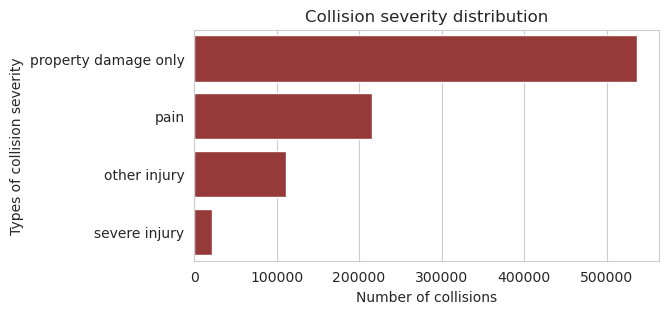

In [24]:
# Univariate Analysis

# Collision Severity Distribution
coll_sevr_dist = clean_tables['collisions'].select("collision_severity").groupby("collision_severity").count()
coll_sevr_dist.show()

import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas
coll_sevr_dist_df = coll_sevr_dist.toPandas() 
# Plot
sns.set_style(style = "whitegrid")
plt.figure(figsize=(6,3))
sns.barplot(coll_sevr_dist_df, y = "collision_severity", x  = "count", color = "brown")
plt.title("Collision severity distribution") 
plt.xlabel("Number of collisions")
plt.ylabel("Types of collision severity") 
plt.show()

## **3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

+-------+------+
|weather| count|
+-------+------+
|   wind|   352|
|  other|   735|
|snowing|  1309|
|    fog|  3678|
|raining| 30533|
| cloudy|116925|
|  clear|730355|
+-------+------+



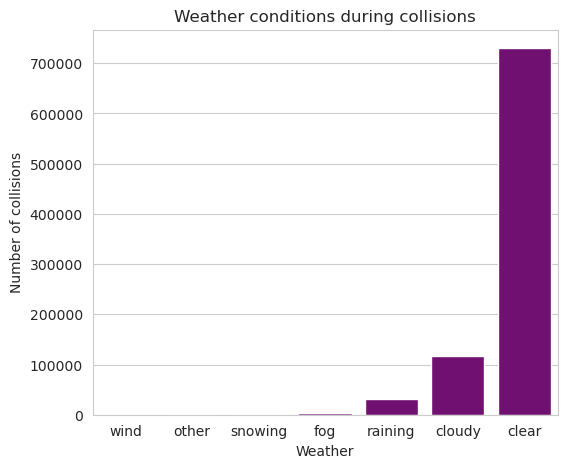

In [25]:
# Weather Conditions During Collisions
weather  = clean_tables['collisions'].select("weather").groupBy("weather").count().orderBy("count")
weather.show()
# Convert to Pandas
weather_df = weather.toPandas()
# Plot
plt.figure(figsize=(6,5))
sns.set_style(style = "whitegrid")
sns.barplot(weather_df, x = "weather", y = "count", color = "purple")
plt.title("Weather conditions during collisions") 
plt.xlabel("Weather") 
plt.ylabel("Number of collisions")
plt.show()


## **3.1.4. Victims Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

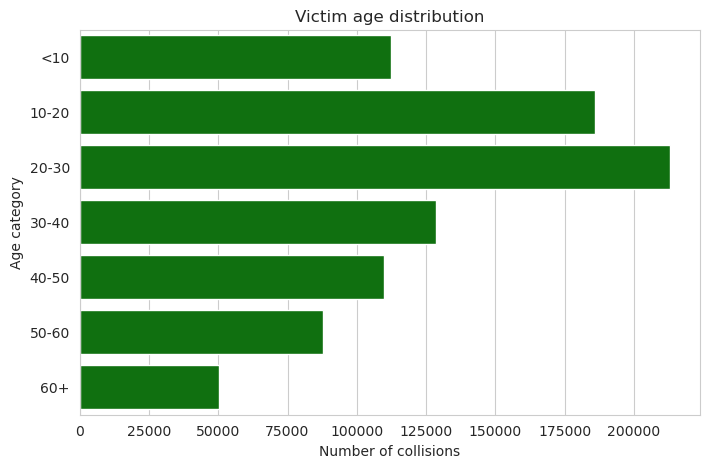

In [26]:
# Distribution of Victim Ages
victim_age = clean_tables['victims'].select("victim_age")

# Convert to Pandas
victim_age_df = victim_age.toPandas() 
bins = [0,10,20,30,40,50,60,70]
labels = ["<10", "10-20", "20-30", "30-40", "40-50", "50-60", "60+"]
age_df = pd.cut(victim_age_df.victim_age, bins = bins, labels = labels, right = False)
# Plot
plt.figure(figsize=(8,5))
sns.countplot(age_df, color = "green")
plt.title("Victim age distribution") 
plt.xlabel("Number of collisions")
plt.ylabel("Age category")
plt.show()

## **3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

+--------------------+---------------+--------------+
|  collision_severity|Injured victims|Killed victims|
+--------------------+---------------+--------------+
|property damage only|            0.0|           0.0|
|                pain|       294921.0|           0.0|
|        other injury|       168250.0|           0.0|
|       severe injury|        34394.0|           0.0|
+--------------------+---------------+--------------+



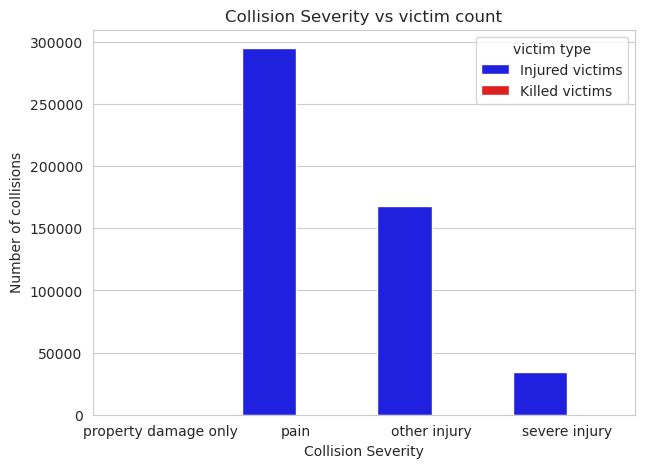

In [27]:
# Bivariate Analysis

# Collision Severity vs. Number of Victims
coll_sevr_vs_victims = clean_tables['collisions'].select("collision_severity", "injured_victims", "killed_victims") \
                                                 .groupBy("collision_severity") \
                                                 .agg( 
                                                     sum("injured_victims").alias("Injured victims"),
                                                     sum("killed_victims").alias("Killed victims"))
coll_sevr_vs_victims.show()                                 
# Convert to Pandas
coll_sevr_vs_victims_df = coll_sevr_vs_victims.toPandas()
plot_df = coll_sevr_vs_victims_df.melt(id_vars = "collision_severity", var_name = "victim type", value_name= "total_count")
# Plot
plt.figure(figsize=(7,5))
sns.barplot( plot_df , x = "collision_severity" , y = "total_count", hue = "victim type", palette = ["blue", "red"], legend = "full")
plt.title("Collision Severity vs victim count")
plt.xlabel("Collision Severity") 
plt.ylabel("Number of collisions")
plt.show()

## **3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

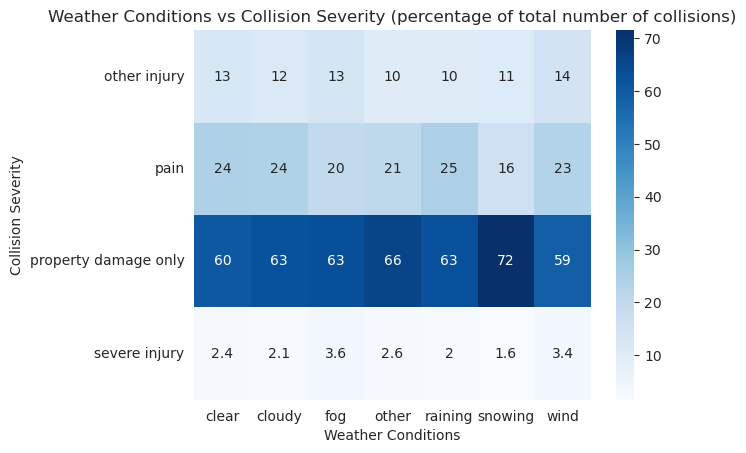

In [28]:
# Weather vs. Collision Severity
weather_severity = clean_tables['collisions'].select("collision_severity", "weather").groupBy("collision_severity", "weather").count()

# Convert to Pandas
weather_severity_df = weather_severity.toPandas()
# df_corr = weather_severity_df.corr()
heatmap_df = weather_severity_df.pivot(columns = "weather", index = "collision_severity", values  = "count")
# Plot
# plt_df = heatmap_df/ heatmap_df.values.sum() *100
plt_df = (heatmap_df / heatmap_df.sum(axis=0)) * 100
sns.heatmap(plt_df, cmap ="Blues", annot= True)
plt.xlabel("Weather Conditions") 
plt.ylabel("Collision Severity") 
plt.title("Weather Conditions vs Collision Severity (percentage of total number of collisions)")
plt.show()

## **3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

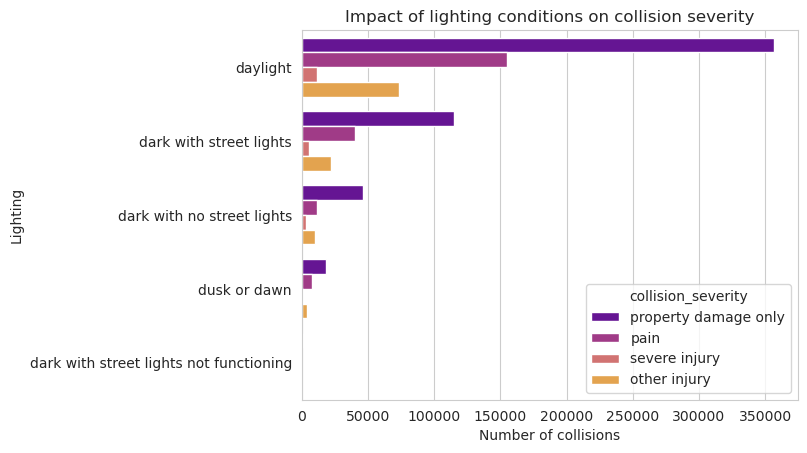

In [29]:
# Lighting Conditions vs. Collision Severity
lighting_collision = clean_tables['collisions'].select("lighting", "collision_severity").groupBy("lighting", "collision_severity").count()
# Convert to Pandas
lighting_df = lighting_collision.toPandas()
# Plot
sns.barplot(lighting_df, y = "lighting", x = "count", hue = "collision_severity", palette= "plasma")
plt.title("Impact of lighting conditions on collision severity") 
plt.xlabel("Number of collisions")
plt.ylabel("Lighting")
plt.show()

## **3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

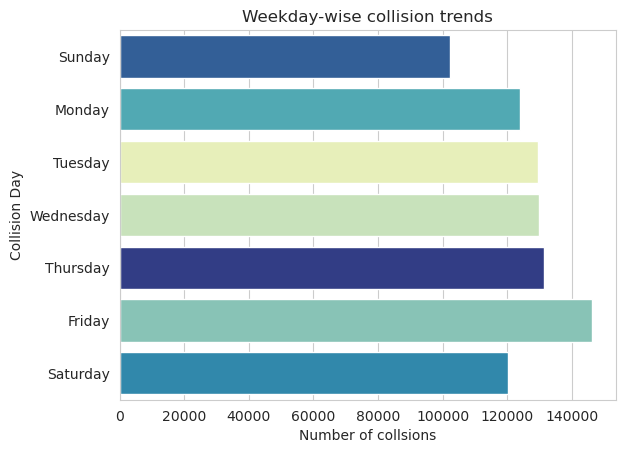

In [30]:
# Extract the weekday
collision_date = clean_tables['collisions'].select("collision_date")
date_df = pd.to_datetime(collision_date.toPandas().collision_date).to_frame()
date_df["collision_day"] = date_df.collision_date.dt.day_name()
order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

# Plot
sns.countplot(date_df, y = "collision_day" , order = order, hue = "collision_day", palette = "YlGnBu", legend = False)
plt.xlabel("Number of collsions")
plt.ylabel("Collision Day") 
plt.title("Weekday-wise collision trends")
plt.show()

## **3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

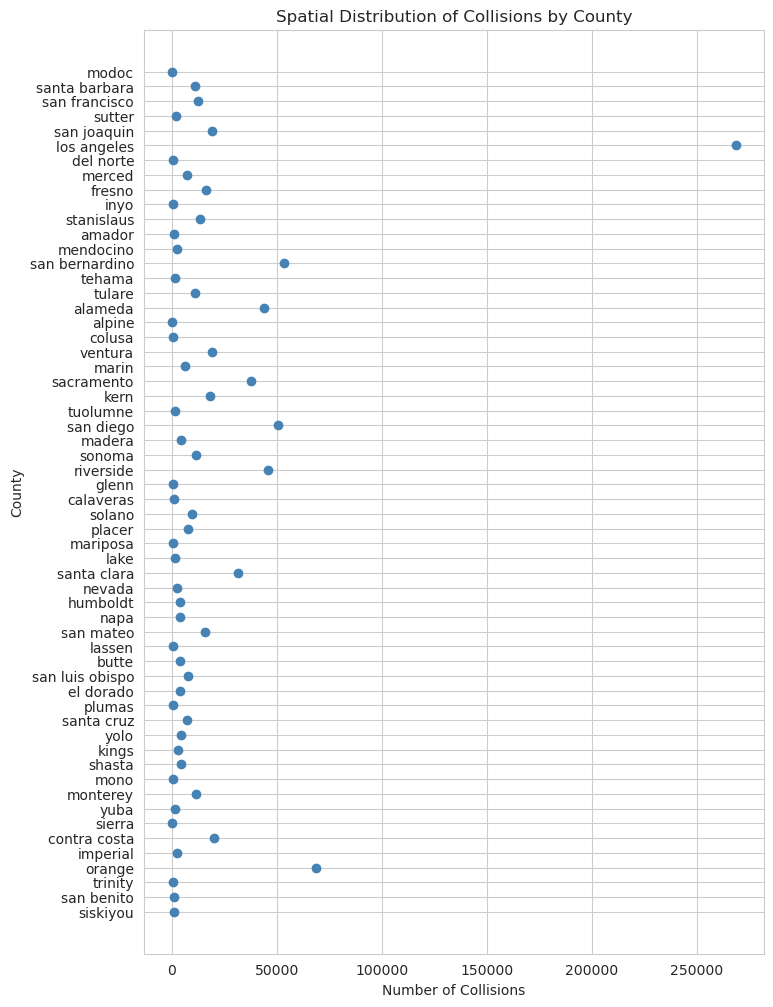

In [31]:
# Spatial Analysis
# Collision Density by County
county_counts = clean_tables['collisions'].select("county_location").groupBy("county_location").count()
county_counts_df = county_counts.toPandas()

# Plot the map
plt.figure(figsize=(8, 12))
plt.scatter(county_counts_df["count"],
            county_counts_df["county_location"],
            color="steelblue")

plt.xlabel("Number of Collisions")
plt.ylabel("County")
plt.title("Spatial Distribution of Collisions by County")
plt.show()


## **3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

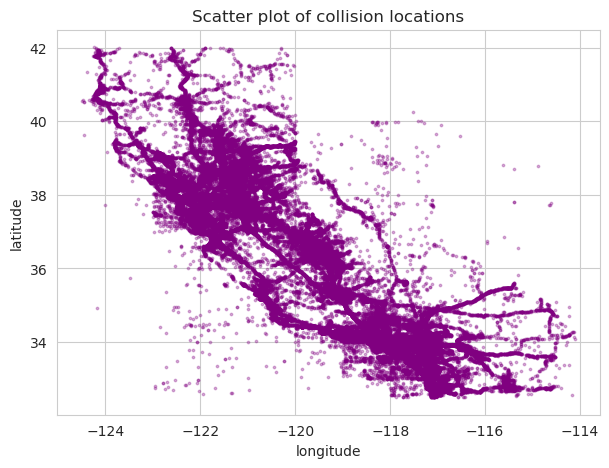

In [32]:
# Scatter Plot of Collision Locations

# Convert PySpark DataFrame to Pandas, handling potential missing values
location_analysis = clean_tables['collisions'].select("latitude", "longitude").dropna()
location_df = location_analysis.toPandas()
# Convert to numeric (if needed) and handle invalid data
## datatype is already in float64 , doesn't need converstion.
# Plot the scatter plot
location_df.plot(y = "latitude", x = "longitude", kind = "scatter", color = "purple", 
                 s = 3, alpha = 0.3, figsize = (7,5), title= "Scatter plot of collision locations")
plt.show()

## **3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [33]:
from pyspark.sql.functions import year, month, hour, to_timestamp, col

# Extract year and month from collision_date
datetime_df = clean_tables['collisions'].withColumns(
                                    {
                                        "year": year("collision_date"), 
                                        "month" : month("collision_date"),
                                        "hour": hour("collision_time")
                                        }
                                                        )
# Plot

Q: Analyze yearly, monthly and hourly trends in collisions.

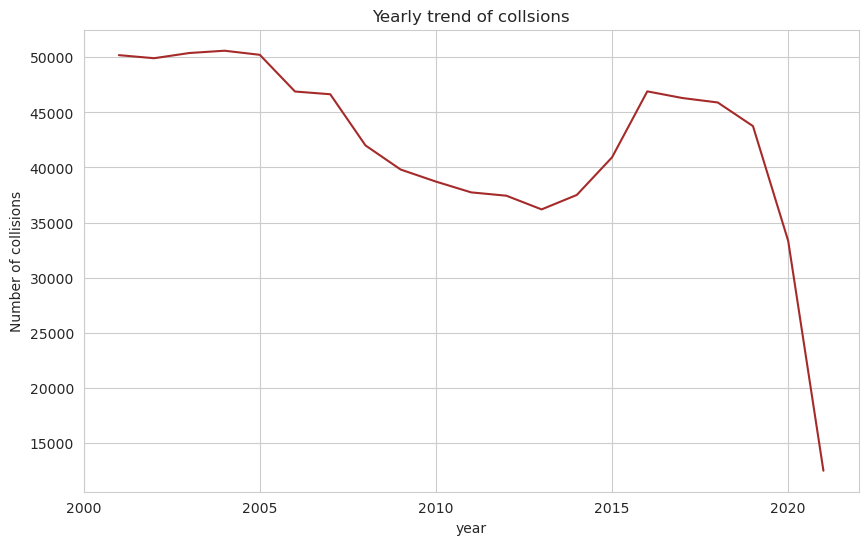

In [34]:
# Yearly Trend of Collisions
year_df = datetime_df.groupBy("year").count().toPandas()
# Plot
plt.figure(figsize=(10,6))
sns.lineplot(year_df , x = "year", y = "count", color = "brown")
plt.xticks(ticks = [2000, 2005, 2010, 2015, 2020])
plt.ylabel("Number of collisions")
plt.title("Yearly trend of collsions")
plt.show()


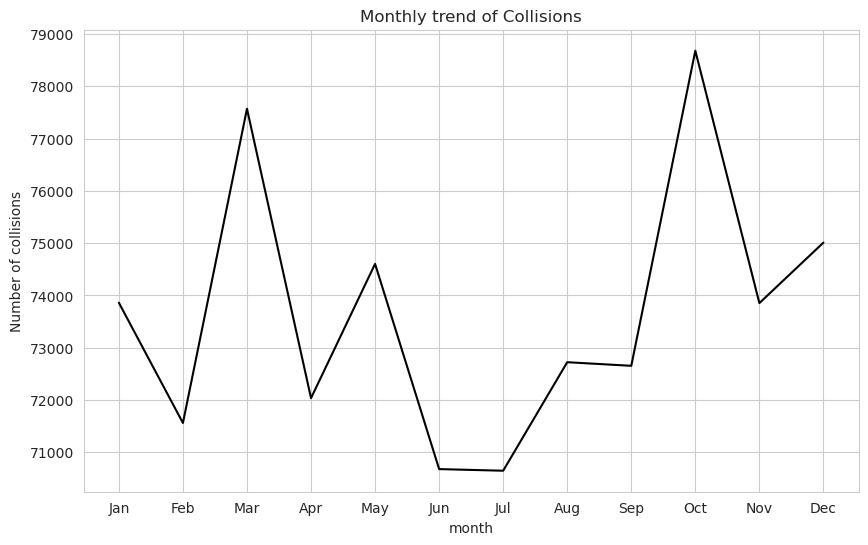

In [35]:
# Monthly Trend of Collisions
import numpy as np
month_df = datetime_df.groupBy("month").count().toPandas()
# Plot
plt.figure(figsize=(10,6))
sns.lineplot(month_df, x= "month", y = "count", color = "black")
plt.xticks(ticks= np.arange(1,13), labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.title("Monthly trend of Collisions")
plt.ylabel("Number of collisions")
plt.show()

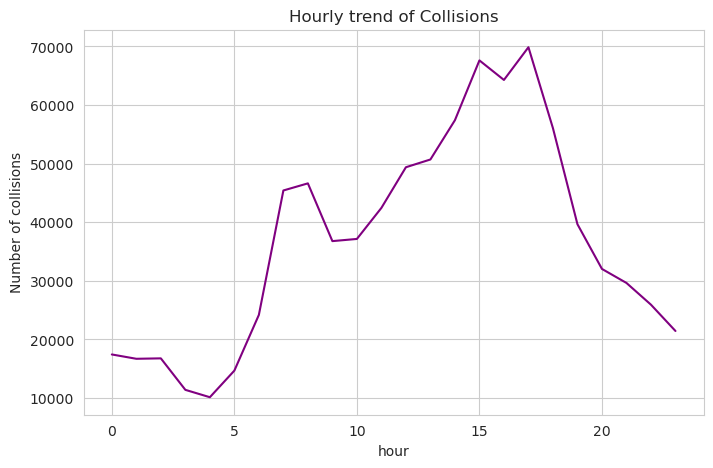

In [36]:
# Hourly Trend of Collisions
hour_df = datetime_df.groupBy("hour").count().toPandas()
# Plot
plt.figure(figsize= (8,5))
sns.lineplot(hour_df, x= "hour", y = "count", color = "purple")
plt.title("Hourly trend of Collisions")
plt.ylabel("Number of collisions")
plt.show()

# **4. ETL Querying** <font color = red>[35 marks]</font> <br>

## **4.1 Loading the Dataset** <font color = red>[1 marks]</font> <br>

Q: Load the processed dataset as CSV files .

In [ ]:
# Write your query here
for name, df in clean_tables.items():
    df.coalesce(1).write.mode("overwrite").csv(f"Output/traffic_data_cleaned_csv/cleaned_{name}")



I manually uploaded the files to google drive , that can be accesed from [here](https://drive.google.com/drive/folders/1sd4fiMHXCp1x4hEhk53Q0yo2NuS_SxFF?usp=sharing)

## **4.2. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [38]:
# Query: Identify the top 5 counties with the most collisions
print("These are the top 5 counties with the most collisions: ")
clean_tables['collisions'].groupBy("county_location").count().orderBy("count", ascending = False).show(5)

These are the top 5 counties with the most collisions: 
+---------------+------+
|county_location| count|
+---------------+------+
|    los angeles|268427|
|         orange| 68601|
| san bernardino| 53545|
|      san diego| 50503|
|      riverside| 45784|
+---------------+------+
only showing top 5 rows



## **4.3. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [39]:
# Query: Find the month with the highest number of collisions
from pyspark.sql.functions import date_format
top = clean_tables['collisions'].withColumn("month", date_format("collision_date", "MMM")) \
                                .groupBy("month").count().orderBy("count", ascending = False).collect()[0]
print("This is the month with the highest number of collisions: ")
print(top.month)

This is the month with the highest number of collisions: 
Oct


## **4.4. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [40]:
# Query: Find the most common weather condition during collisions
top = clean_tables['collisions'].groupBy("weather").count().orderBy("count", ascending = False).collect()[0]

print("This is most common weather condition during collisions: ") 
print(top.weather)

This is most common weather condition during collisions: 
clear


## **4.5. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [41]:
# Query: Determine the percentage of collisions that resulted in fatalities
fatalities = clean_tables['collisions'].filter(col("killed_victims") != 0).count()/ clean_tables['collisions'].count()
print("This is percentage of collisions that resulted  to fatalities: ", fatalities)

This is percentage of collisions that resulted  to fatalities:  0.0


## **4.6. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [42]:
# Query: Find the most dangerous time of day for collisions
dangerous_hour = clean_tables['collisions'].withColumn("hour", hour("collision_time")) \
                                    .groupBy("hour").count() \
                                    .orderBy("count", ascending = False).collect()[0]

print("Most dangerous time of day for collisions: " , dangerous_hour.hour)

Most dangerous time of day for collisions:  17


## **4.7. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [43]:
# Query: List the top 5 road types with the highest collision frequency
top_5 = clean_tables['collisions'].groupBy("road_condition").count().orderBy("count", ascending = False)
print("The top 5 road types with the highest collision frequency: ", top_5.show(5))

+--------------+------+
|road_condition| count|
+--------------+------+
|        normal|857198|
|  construction| 14610|
|   obstruction|  3494|
|         other|  3158|
|         holes|  2071|
+--------------+------+
only showing top 5 rows

The top 5 road types with the highest collision frequency:  None


## **4.8. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [44]:
# Query: Find the top 3 lighting conditions that lead to the most collisions
top_3 = clean_tables['collisions'].groupBy("lighting").count().orderBy("count", ascending = False).limit(3).collect()
print("The top 3 lighting conditions that lead to the most collisions : ")
for top in top_3: 
    print(top.lighting)

The top 3 lighting conditions that lead to the most collisions : 
daylight
dark with street lights
dark with no street lights


# 5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

## Final insights
1. Most of the collisions are not severe . The majority result in property damage only.

2. Clear weather and daylight account for the highest number of collisions. It sounds absurd but because traffic volume is highest in these conditions.

3. Young adults (20–30 years) are the most affected age group in collisions.(expected due to their risk taking behaviour)

4. Collisions are not evenly distributed across days: They peak on weekdays (especially Friday).

5. A few high-population counties contribute disproportionately to total collisions.

6. Over the years, collisions show fluctuations, with a sharp drop in recent years.It should be because of reduced travel but it must be analysed further.

## Recommnedations 
1. Most accidents happen in clear weather and daytime, so drivers should not be careless just because conditions look safe.

2. Young drivers (20–30 years) are involved in more accidents, so they need more awareness and stricter traffic rules.

3. Accidents are higher on weekdays, especially Fridays, so traffic control should be stronger on these days.

4. Even though serious injuries are less, safety rules like speed limits, helmets, and seat belts should be followed strictly.

5. Cities and highly populated areas need better road planning and traffic management to reduce accidents.

6. Good street lighting should be maintained to improve safety at night.